***RELOAD DATA & LIBRARY***

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    f1_score,
    roc_auc_score
)
# for save and load model
import joblib
import json
import os

#Show all columns, without hiding any
pd.set_option('display.max_columns', None)

**2. Data Preparing**

In [5]:
df_featured = pd.read_csv("..\\Data\\Processed\\data_featured.csv")

In [6]:
# 1. DEFINE X AND y

target_col = 'is_hit'

y = df_featured[target_col]

# Đưa drop feature vào data cleaning
drop_cols = [
    'is_hit',
    'track_popularity',
    'track_id',
    'track_name',
    'artist_name',
    'artist_genres',
    'album_name',
    'album_release_date'
]

X = df_featured.drop(columns=drop_cols, errors='ignore')

print("Feature matrix X shape:", X.shape)
print("Target y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature matrix X shape: (8582, 32)
Target y shape: (8582,)

Feature columns:
['track_number', 'explicit', 'artist_popularity', 'artist_followers', 'album_id', 'album_total_tracks', 'album_type', 'track_duration_min', 'release_year', 'release_month', 'duration_level', 'track_duration_sq', 'is_short_song', 'song_age', 'is_recent_song', 'release_season', 'artist_followers_log', 'artist_is_popular', 'artist_power_score', 'is_single_album', 'is_lead_track', 'track_position_ratio', 'genre_count', 'genre_pop', 'genre_rap', 'genre_rock', 'genre_hip_hop', 'genre_dance', 'genre_latin', 'artist_pop_x_followers', 'duration_x_artist_pop', 'explicit_x_artist_pop']


In [7]:
# 4. CREATE PREPROCESSING TRANSFORMER

numerical_cols = ['track_number', 'artist_popularity', 'artist_followers', 
                  'album_total_tracks', 'track_duration_min', 'release_year', 
                  'release_month', 'track_duration_sq', 'is_short_song', 'song_age', 
                  'is_recent_song', 'artist_followers_log', 'artist_is_popular', 
                  'artist_power_score', 'is_single_album', 'is_lead_track', 
                  'track_position_ratio', 'genre_count', 'genre_pop', 'genre_rap', 
                  'genre_rock', 'genre_hip_hop', 'genre_dance', 'genre_latin', 'artist_pop_x_followers',
                    'duration_x_artist_pop', 'explicit_x_artist_pop']

categorical_cols = ['explicit', 'album_id', 'album_type', 'duration_level', 'release_season']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

print("Preprocessing transformer created successfully.")

Preprocessing transformer created successfully.


***DATA SPLITING***


In [8]:
# =========================================================
# TIME-BASED SPLIT
# =========================================================

TRAIN_END = 2021
VAL_END = 2023

# -------------------------
# TRAIN SET
# <= 2021
# -------------------------
train = df_featured[
    df_featured["release_year"] <= TRAIN_END
]

# -------------------------
# VALIDATION SET
# 2022 - 2023
# -------------------------
val = df_featured[
    (df_featured["release_year"] > TRAIN_END) &
    (df_featured["release_year"] <= VAL_END)
]

# -------------------------
# TEST SET
# 2024+
# -------------------------
test = df_featured[
    df_featured["release_year"] > VAL_END
]

# =========================================================
# DROP COLUMNS
# =========================================================

DROP_FROM_X = [
    "is_hit",
    "track_popularity",
    "album_release_date"
]

# =========================================================
# SPLIT X AND y
# =========================================================

def xy(df):

    # Features
    X = df.drop(
        columns=DROP_FROM_X,
        errors="ignore"
    )

    # Target
    y = df["is_hit"]

    return X, y

# =========================================================
# CREATE TRAIN / VAL / TEST DATA
# =========================================================

X_train, y_train = xy(train)

X_val, y_val = xy(val)

X_test, y_test = xy(test)

# =========================================================
# TRAIN + VAL FOR FINAL FIT
# =========================================================

fit_df = pd.concat(
    [train, val],
    ignore_index=True
)

X_fit, y_fit = xy(fit_df)

# =========================================================
# CHECK SPLIT
# =========================================================

print(
    f"train: n={len(train):>6,d}  "
    f"hit rate={y_train.mean():.3f}"
)

print(
    f"val:   n={len(val):>6,d}  "
    f"hit rate={y_val.mean():.3f}"
)

print(
    f"test:  n={len(test):>6,d}  "
    f"hit rate={y_test.mean():.3f}"
)

# =========================================================
# CHECK YEAR RANGE
# =========================================================

print("\nYear ranges:")

print(
    f"Train: "
    f"{train['release_year'].min()} "
    f"-> "
    f"{train['release_year'].max()}"
)

print(
    f"Val:   "
    f"{val['release_year'].min()} "
    f"-> "
    f"{val['release_year'].max()}"
)

print(
    f"Test:  "
    f"{test['release_year'].min()} "
    f"-> "
    f"{test['release_year'].max()}"
)

train: n= 6,178  hit rate=0.063
val:   n=   991  hit rate=0.057
test:  n= 1,413  hit rate=0.103

Year ranges:
Train: 1952 -> 2021
Val:   2022 -> 2023
Test:  2024 -> 2025


***PIPLINE***

In [9]:
# =========================================================
# COLUMN TYPES
# =========================================================

categorical_cols = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    include=["int64", "float64", "Int64"]
).columns.tolist()

print("Categorical:")
print(categorical_cols)

print("\nNumeric:")
print(numeric_cols)

# =========================================================
# PREPROCESSOR
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

Categorical:
['explicit', 'artist_genres', 'album_id', 'album_type', 'duration_level', 'release_season']

Numeric:
['track_number', 'artist_popularity', 'artist_followers', 'album_total_tracks', 'track_duration_min', 'release_year', 'release_month', 'track_duration_sq', 'is_short_song', 'song_age', 'is_recent_song', 'artist_followers_log', 'artist_is_popular', 'artist_power_score', 'is_single_album', 'is_lead_track', 'track_position_ratio', 'genre_count', 'genre_pop', 'genre_rap', 'genre_rock', 'genre_hip_hop', 'genre_dance', 'genre_latin', 'artist_pop_x_followers', 'duration_x_artist_pop', 'explicit_x_artist_pop']


***MODEL TUNING***

In [16]:
# =========================================================
# OBJECTIVE FUNCTION
# =========================================================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            20
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split",
            2,
            20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf",
            1,
            10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2"]
        ),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
    }

    rf_pipe = Pipeline([
        ("pre", preprocessor),

        ("clf", RandomForestClassifier(
            **params,
            random_state=42,   
            n_jobs=-1
        ))
    ])

    rf_pipe.fit(X_train, y_train)

    y_pred = rf_pipe.predict(X_val)
    y_proba = rf_pipe.predict_proba(X_val)[:, 1]

    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_proba)

    # optimize kết hợp
    score = 0.5 * f1 + 0.5 * auc

    return score


# =========================================================
# FIX RANDOM SEED FOR OPTUNA
# =========================================================

sampler = optuna.samplers.TPESampler(
    seed=42
)


# =========================================================
# RUN STUDY
# =========================================================

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=50   
)

print("Best score:")
print(study.best_value)

print("\nBest params:")
print(study.best_params)

[I 2026-05-20 10:02:21,335] A new study created in memory with name: no-name-2b07c208-cf07-4456-a2f3-9b1bba3fab6e
[I 2026-05-20 10:02:22,103] Trial 0 finished with value: 0.5209508899799185 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5209508899799185.
[I 2026-05-20 10:02:23,089] Trial 1 finished with value: 0.5062570108595797 and parameters: {'n_estimators': 341, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5209508899799185.
[I 2026-05-20 10:02:23,798] Trial 2 finished with value: 0.5178540757061403 and parameters: {'n_estimators': 222, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5209508899799185.
[I 2026-05-20 10:02:24,712] Trial 3 finished w

Best score:
0.5275537019110212

Best params:
{'n_estimators': 170, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced'}


***FINAL TRAINING ON TEST SET***

In [11]:
best_params = study.best_params

rf_pipe = Pipeline([
    ("pre", preprocessor),

    ("clf", RandomForestClassifier(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_fit, y_fit)

print("Final model trained.")

Final model trained.


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

# =========================================================
# PREDICT
# =========================================================

y_pred = rf_pipe.predict(X_test)

y_proba = rf_pipe.predict_proba(X_test)[:, 1]

# =========================================================
# METRICS
# =========================================================

print("=== Classification Metrics ===")

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")

print("\n=== Probability Metrics ===")

print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Log Loss  : {log_loss(y_test, y_proba):.4f}")
print(f"Brier     : {brier_score_loss(y_test, y_proba):.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Metrics ===
Accuracy  : 0.7693
Precision : 0.2353
Recall    : 0.5479
F1-score  : 0.3292

=== Probability Metrics ===
ROC-AUC   : 0.8003
Log Loss  : 0.4323
Brier     : 0.1368

=== Confusion Matrix ===
[[1007  260]
 [  66   80]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      1267
           1       0.24      0.55      0.33       146

    accuracy                           0.77      1413
   macro avg       0.59      0.67      0.59      1413
weighted avg       0.87      0.77      0.81      1413



Compared to the baseline Random Forest model, the model after feature engineering showed significant improvement in identifying the minority class (“Hit”). Although the overall accuracy decreased from 93% to 77%, the recall increased substantially from 0.09 to 0.57, while the F1-score improved from 0.15 to 0.34. This indicates that the model became much more effective at detecting positive cases instead of mainly predicting the majority class (“Not Hit”).

These results show that feature engineering helped the model learn more meaningful patterns and relationships from the dataset. For an imbalanced classification problem, the improvement in recall and F1-score is more important than overall accuracy, as the main objective is to correctly identify “Hit” cases.

***FEATURE IMPORTANCE***

                       feature  importance
11        artist_followers_log    0.098373
13          artist_power_score    0.090947
24      artist_pop_x_followers    0.082176
12           artist_is_popular    0.078887
1            artist_popularity    0.067607
2             artist_followers    0.063228
25       duration_x_artist_pop    0.057061
4858          album_type_album    0.035018
3           album_total_tracks    0.028310
16        track_position_ratio    0.022545
4           track_duration_min    0.020651
545   artist_genres_soundtrack    0.018461
9                     song_age    0.017555
7            track_duration_sq    0.016299
0                 track_number    0.015969
5                 release_year    0.013360
6                release_month    0.013357
26       explicit_x_artist_pop    0.012320
4859    album_type_compilation    0.012157
4860         album_type_single    0.012018


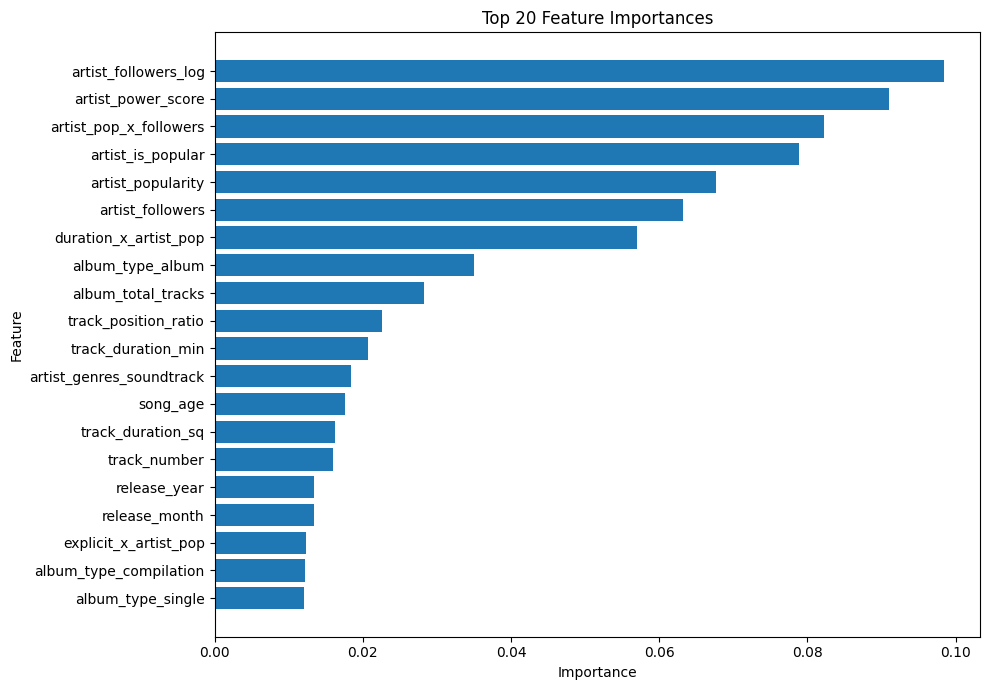

In [13]:
# =========================================================
# GET FEATURE NAMES AFTER PREPROCESSING
# =========================================================

ohe = rf_pipe.named_steps["pre"].named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = (
    numeric_cols +
    list(cat_feature_names)
)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importances = (
    rf_pipe.named_steps["clf"]
    .feature_importances_
)

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
})

feat_imp = feat_imp.sort_values(
    by="importance",
    ascending=False
)

print(feat_imp.head(20))

# =========================================================
# PLOT TOP FEATURES
# =========================================================

top_n = 20

top_feat = feat_imp.head(top_n)

plt.figure(figsize=(10, 7))

plt.barh(
    top_feat["feature"][::-1],
    top_feat["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances")

plt.tight_layout()
plt.show()

## **SAVING MODEL AND PARAMS**

In [14]:
# =========================================================
# CREATE FOLDER
# =========================================================

os.makedirs("../models", exist_ok=True)

# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    rf_pipe,
    "../models/random_forest_pipeline.pkl"
)

print("Random Forest model saved.")

# =========================================================
# SAVE BEST PARAMS
# =========================================================

with open("../models/rf_best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)

print("Best params saved.")

Random Forest model saved.
Best params saved.


In [15]:
# load model

rf_loaded = joblib.load(
    "../models/random_forest_pipeline.pkl"
)

# load params
with open("../models/rf_best_params.json", "r") as f:
    rf_params = json.load(f)

print(rf_params)

{'n_estimators': 170, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced'}
